# AI Machine Learning Foundations – Assignment 1
## Data Preparation Pipeline for Bank Marketing Dataset

Name: Haya Mourad

Course: AI – Machine Learning Foundations  

Professor: Matteo Turilli

Date: March 2026

GitHub Repository:


## Objectives

With the help of the Bank Marketing dataset, this first individual assignment aims to build a disciplined data preparation pipeline. The focus is not on maximizing predictive performance, but on:

- explore and critically analyze the structure and characteristics of a real-world dataset;
- identify and properly handle explicit and implicit missing values;
- encode categorical variables and justify the encoding strategy adopted;
- select and justify an appropriate feature scaling strategy for numerical variables;
- split the data into training, validation, and test sets using an appropriate stratification strategy;
- address class imbalance and discuss its impact on model evaluation
- perform principled feature selection while avoiding data leakage; and
- train a simple Logistic Regression model as a consistency check of the data preparation pipeline

## 1. Identifying the Prediction Target

Finding the appropriate prediction target in this assignment builds the foundation for everything else. Looking at the variables, it seems clear that it is the variable `y`, which shows if a client subscribed to a term deposit following contact during the marketing campaign or not.

This introduces a **binary classification task**, with:
- `y = "yes"` for subscription,
- `y = "no"` for else.

Predicting this outcome (business objective) using information at our disposal is the final and correct aim.

`y` is now encoded as a binary variable (1 = yes, 0 = no), for modelling purposes.

### Variables That Should Not Be Treated as Targets

There are other present variables also related to campaign performance, however it is critical to note that they do not represent the prediction objective:

- **`duration`**: This variable, which is only known after the interaction has taken place, keeps track of the call duration. Its use would result in temporal leakage and a violation of the prediction-time constraint.
- **`campaign`**: This variable shows how many contacts were made throughout the campaign (campaign activity)
- **`poutcome`**: This variable does not reflect the current prediction objective; rather, it describes the result of a prior campaign.

This logic shows that the only variable that accurately reflects the intended learning task is `y`.

## 2. Data Loading and Initial Exploration

The dataset is given in the assignment instructions and loaded from the file named `bank-additional.csv`. Every row represents a client that was reached during the campaign.

Step 1 will:

- output the number of variables and observations,
- classify data types (categorical/ numerical),
- study the dataset structure,
- better understandinf of the target distribution.

This structural step offers deep understanding of the dataset and must happen before any preprocessing decisions can be made.

In [48]:
# Load Dataset
import pandas as pd

df = pd.read_csv("bank-additional.csv", sep=";")
print("Dataset loaded successfully.")


Dataset loaded successfully.


In [49]:
# Dataset Structural Overview
print("\nDataset shape:", data.shape)

print("\nFirst five rows:")
display(data.head())

print("\nDataset info:")
data.info()


Dataset shape: (4119, 21)

First five rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   41

In [50]:
print("\nTarget variable distribution:")
display(data["y"].value_counts())

print("\nTarget variable proportions:")
display(data["y"].value_counts(normalize=True))


Target variable distribution:


,count
y,
no,3668
yes,451



Target variable proportions:


,proportion
y,
no,0.890507
yes,0.109493


### Target Distribution and Class Imbalance

There is a significant class imbalance in the target variable. Just about 11% of observations relate to successful term deposit subscriptions, whereas 89% of observations relate to clients who did not subscribe.

Two factors make this imbalance significant:

1. Accuracy alone is a deceptive performance metric because a naïve classifier that consistently predicts "no" would already achieve high accuracy (~89%).
2. The ability of models trained on unbalanced data to accurately identify the minority class ("yes"), which is usually the class of greater business interest, may be compromised by bias toward the majority class.

As a result, class imbalance needs to be specifically addressed later in the pipeline by applying suitable resampling techniques solely to the training set.

## 3. Exploratory Data Analysis

The next step studies some numerical and categorical variables to understand their distributions and use in modeling. The objective is targeted deep inspection rather than exhaustive visualization, to inform preprocessing decisions. It is crucial.

### 3.1 Numerical Variables

We look at two numerical variables: `age` and `euribor3m`. Each of these variables reflect macroeconomic and demographic traits, respectively.  

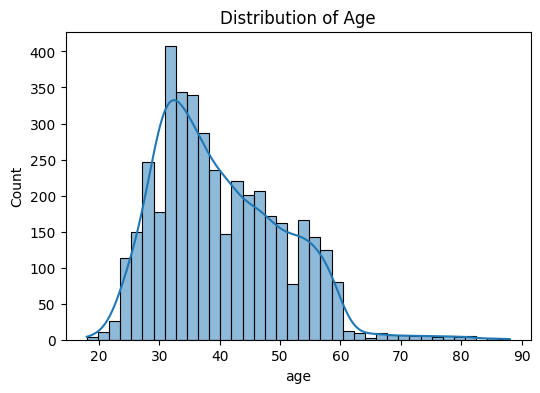

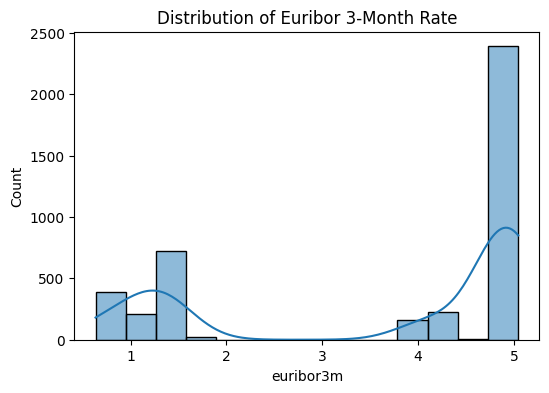

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(df["age"], kde=True)
plt.title("Distribution of Age")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["euribor3m"], kde=True)
plt.title("Distribution of Euribor 3-Month Rate")
plt.show()

With a concentration of clients between roughly 25 and 50 years old, the `age` distribution seems to be somewhat skewed to the right. Although they are rare, extreme values should be taken into account when using scaling techniques.

Macroeconomic periods are reflected in the clustering of the variable `euribor3m` around particular values. Feature scaling will be necessary prior to model training because this variable is continuous and measured on a different scale than other numerical variables.

### 3.2 Categorical Variables

Two categorical variables that represent client-level characteristics that could affect subscription behavior are examined: `job` and `education`.

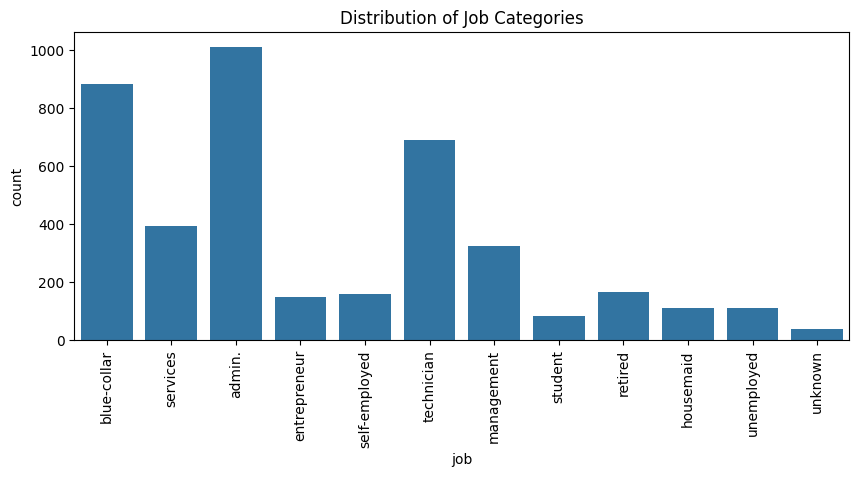

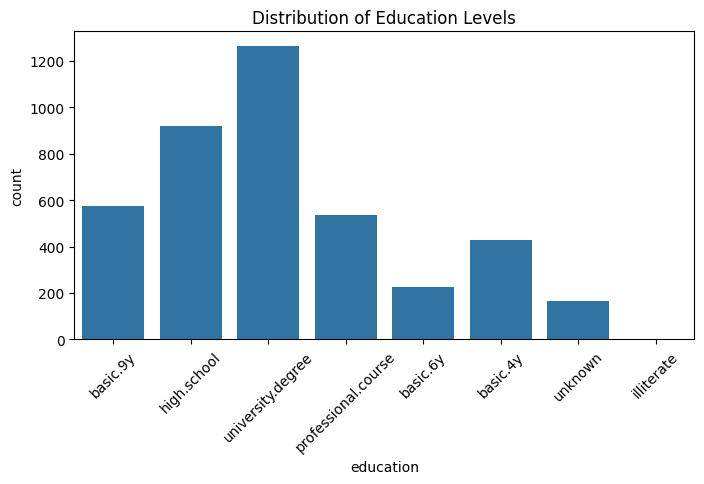

In [52]:
plt.figure(figsize=(10,4))
sns.countplot(x="job", data=df)
plt.xticks(rotation=90)
plt.title("Distribution of Job Categories")
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x="education", data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Education Levels")
plt.show()

The distribution of `job` shows several categories with different frequencies, one of which is the "unknown" category, which stands for implicit missingness.

Likewise, `education` includes both the "unknown" category and ordered levels. Implicit missing values imply that encoding and handling of missing values need to be thoroughly justified during preprocessing.

### 3.3 Variable Requiring Special Consideration

Particular consideration must be given to the variable `duration`. It is only known after the interaction has taken place and indicates the duration of the phone call. Including `duration` would result in temporal data leakage because the prediction task's goal is to estimate subscription at the moment of contact.

In order to guarantee a realistic and reliable predictive setup, this variable will be eliminated before model training.

## 4. Data Splitting

The next step before preprocessing allows us to split our dataset into three parts: training, validation, and test sets.

This ordering will save us from potential data leakage. transformations like scaling, imputation, encoding, resampling among others learns parameters from data. This is why they must only be fitted on the training set.

We will split by 60/20/20:
- 60% training set
- 20% validation set
- 20% test set

 With respect to the target variable, stratified sampling is applied and allows us to preserve the correct class distribution for all subsets.

In [53]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("y", axis=1)
y = df["y"].map({"yes": 1, "no": 0})

# First split: training (60%) and temporary (40%)
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Second split: validation (20%) and test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Training set:", X_train_full.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (2471, 20)
Validation set: (824, 20)
Test set: (824, 20)


The fraction of subscription outcomes ("yes" and "no") is kept roughly constant throughout the training, validation, and test with stratification.

Unreliable evaluation could result from some subsets of the dataset having disproportionately few positive cases if the dataset were divided without stratification.

Information from the validation or test sets could affect model training if splitting were done after preprocessing (such as scaling or resampling), causing data leakage and excessive optimistic performance estimates.

## 5. Removing Leakage Variables

As previously mentionned, The length of the phone call is recorded by the variable `duration`, which is only known after the interaction has taken place. Adding this variable would result in temporal data leakage because the goal is to predict subscription at the moment of contact.

As a result, prior to additional preprocessing, `duration` is eliminated from every subset.

In [54]:
# Remove duration from all splits
X_train = X_train_full.drop(columns=["duration"])
X_val = X_val.drop(columns=["duration"])
X_test = X_test.drop(columns=["duration"])

print("Training shape after removal:", X_train.shape)
print("Validation shape after removal:", X_val.shape)
print("Test shape after removal:", X_test.shape)

Training shape after removal: (2471, 19)
Validation shape after removal: (824, 19)
Test shape after removal: (824, 19)


## 6. Managing Missing Values

In this dataset, missingness mostly presents itself implicitly. The label "unknown" is used to indicate missing data for a number of categorical variables. Also, a sentinel value (`999`) is used by the variable `pdays` to indicate that a client has not been contacted before.

To prevent leakage, only the training set is used when making decisions about handling missing values. Parameters learned from the training data are used to transform the validation and test sets.

In [55]:
# Explicit missing values (NaN)
df.isna().sum().sort_values(ascending=False).head(10)

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [56]:
# Count "unknown" occurrences in each categorical column (training set)
cat_cols = X_train.select_dtypes(include="object").columns

unknown_counts = (X_train[cat_cols] == "unknown").sum().sort_values(ascending=False)
unknown_props = (unknown_counts / len(X_train)).sort_values(ascending=False)

unknown_summary = pd.DataFrame({
    "unknown_count": unknown_counts,
    "unknown_prop": unknown_props
})

unknown_summary[unknown_summary["unknown_count"] > 0]

,unknown_count,unknown_prop
default,492,0.199110
education,104,0.042088
housing,55,0.022258
loan,55,0.022258
job,20,0.008094
marital,7,0.002833


The findings reveal that in categorical variables, missingness is typically implicitly encoded as "unknown." The `"unknown"` category will be kept and handled as an informative level during encoding, as opposed to removing these rows, which would shrink the dataset and possibly skew it.

Missingness itself may carry predictive information, so this decision makes sense (e.g., clients that avoid discussing education might act differently).

In [57]:
# Inspect pdays in the training set
X_train["pdays"].describe(), (X_train["pdays"] == 999).mean()

(count    2471.000000
 mean      957.598543
 std       198.554323
 min         0.000000
 25%       999.000000
 50%       999.000000
 75%       999.000000
 max       999.000000
 Name: pdays, dtype: float64,
 np.float64(0.9583164710643464))

In [58]:
import numpy as np

# Create indicator: was previously contacted
for split in [X_train, X_val, X_test]:
    split["previously_contacted"] = (split["pdays"] != 999).astype(int)
    split["pdays"] = split["pdays"].replace(999, np.nan)

The special case "not previously contacted" is encoded by the value `pdays = 999`, which does not actually represent a number of days. A separate indicator feature (`previously_contacted`) is added to keep the information that the client had no prior contact, and 999 is converted to missing (`NaN`) to avoid treating it as a meaningful level.

## 7. Encoding Categorical Variables

Numerical inputs are required for machine learning models. That means categorical variables need to be changed into numbers.

Most of the categorical variables in this dataset are nominal, which means that they don't have an order. Encoding them will be done through one-hot encoding, and that creates binary indicator variables for each category.

To keep the data from leaking, the encoding will only be fitted on the training set.

In [59]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

# Define encoder (handle_unknown prevents errors on validation/test)
encoder = OneHotEncoder(handle_unknown="ignore")

# Apply encoding to categorical columns, keep numeric columns unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, cat_cols)
    ],
    remainder="passthrough"
)

# Fit ONLY on training set
X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded validation shape:", X_val_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded training shape: (2471, 63)
Encoded validation shape: (824, 63)
Encoded test shape: (824, 63)


## 8. Feature Scaling

Regularization penalties in logistic regression are based on the size of the feature coefficients and are optimized using gradient-based techniques. Variables with higher numerical values may have a disproportionate impact on the optimization process if features are measured on different scales.

Standardization is used to guarantee numerical stability and cross-feature comparability. The training set statistics are used to transform each feature to have a mean of 0 and a standard deviation of 1.

Once again, always focusing on avoiding data leakage, the scaler is only fitted to the training data, preventing information from the test or validation sets from affecting the transformation.

## 9. Logistic Regression Model

The processed training data is used to train a Logistic Regression model in order to verify the integrity of the data preparation pipeline.

Verifying that the pipeline generates an orderly and useful feature representation is the goal rather than optimizing predictive performance.

Accuracy, precision, and recall are used to evaluate the model on the validation set. Metrics other than accuracy are taken into consideration because of the class imbalance.

In [60]:
from sklearn.impute import SimpleImputer

# Impute missing numeric values (NaNs created from pdays=999 replacement)
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train_encoded)
X_val_imputed = imputer.transform(X_val_encoded)
X_test_imputed = imputer.transform(X_test_encoded)

print("NaNs in train after imputation:", np.isnan(X_train_imputed).sum())

NaNs in train after imputation: 0


In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train_full)

y_val_pred = log_reg.predict(X_val_scaled)

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred)
rec = recall_score(y_val, y_val_pred)

print("Validation Accuracy:", acc)
print("Validation Precision:", prec)
print("Validation Recall:", rec)
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.8980582524271845
Validation Precision: 0.59375
Validation Recall: 0.2111111111111111

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       734
           1       0.59      0.21      0.31        90

    accuracy                           0.90       824
   macro avg       0.75      0.60      0.63       824
weighted avg       0.88      0.90      0.88       824



### Model Interpretation

On the validation set, the accuracy of the Logistic Regression model is about 90%. However, given the significant class imbalance in the dataset, this value needs to be interpreted with caution.

For the positive class (subscription = 1), recall is comparatively low (about 0.21) while precision is moderate (about 0.63). This suggests that while the model predicts subscriptions with a reasonable degree of accuracy, it misses a significant percentage of real subscribers.

Models tend to favour the majority class ("no") in imbalanced classification problems, which is in tune with this behaviour. For this task, accuracy alone is not a sufficient evaluation metric, and additional imbalance-handling techniques might be necessary.

## 10. Task Ordering and Pipeline Discipline

As covered in the lectures, the preprocessing steps are arranged according to the **pipeline discipline** principle. Preventing data leakage and making sure that model evaluation represents a realistic predictive setting are the main goals.

The chosen sequence is conceptually motivated as follows:

### 1. Problem Formulation
To make a clear distinction between features and outcome, the prediction target (`y`) is defined first. This stops target information from inadvertently being included during preprocessing.

### 2. Data Splitting
Prior to any transformation that learns from data, the dataset is divided into training, validation, and test sets.  

Any operation that computes parameters (such as means, variances, encoding mappings, and resampling structure) must only be fitted on the training set, according to the data leakage lecture material. Biased performance estimates would arise from splitting after such operations, which would allow information from test or validation data to affect the training process.

### 3. Removal of Temporal Leakage
Leakage Since the variable "duration" is unavailable during prediction time, it is eliminated. This adheres to the rule that when making predictions, the feature set must represent information that is actually available.

### 4. Preprocessing Operations That Learn Parameters
Estimators that calculate statistics from data are used in the following steps:
- Imputation (numerical feature median),
One-hot encoding (category structure learning),
- Feature scaling (estimation of variance and mean).

Only the training set is used to fit each of these transformations before being applied to the validation and test sets. This prevents the training phase from being tainted by distributional information from unseen data.

### 5. Model Training and Evaluation
Only the fully processed training data are used to train the Logistic Regression model. Without gaining access to the test set, performance is assessed on the validation set to estimate predictive performance.

---

### Consequences of Incorrect Ordering

The calculated statistics would include data from test and validation observations if scaling or imputation were done before splitting. This results in optimistic bias and breaches the independence assumption between training and evaluation data.

Similarly, because `duration` contains post-outcome information, keeping it would result in temporal leakage.

---

This ordering guarantees that evaluation metrics accurately reflect generalisation performance, maintains dataset independence, and upholds methodological validity.

## 11. Addressing Class Imbalance

Successful subscriptions are represented by the minority class ("yes") in this marketing context. From a business standpoint, missed revenue opportunities could arise from low recall, which is the inability to identify potential subscribers. As a result, increasing minority class detection is usually more important than increasing overall accuracy.

With roughly 11% positive cases ("yes") and 89% negative cases ("no") in the training data, the target variable shows a significant class imbalance.

A classifier may achieve high accuracy in unbalanced settings by accurately identifying minority instances while primarily predicting the majority class. Because of this, accuracy is not a sufficient evaluation metric on its own.

A resampling technique is only used on the training set to address this problem. The initial class distribution is maintained in the test and validation sets.

In [63]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Check class distribution before resampling
print("Before SMOTE:", Counter(y_train_full))

# Apply SMOTE to scaled training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_full)

print("After SMOTE:", Counter(y_train_resampled))

Before SMOTE: Counter({0: 2200, 1: 271})
After SMOTE: Counter({0: 2200, 1: 2200})


By interpolating between current minority observations, SMOTE (Synthetic Minority Over-sampling Technique) creates artificial examples of the minority class.

As part of the model training process, resampling is applied **only to the training set** and **after preprocessing**. Resampling before splitting would introduce artificial information from the training data into the validation and test sets, resulting in skewed evaluation outcomes.

Furthermore, the test and validation sets are not resampled because they need to accurately represent the underlying distribution.

In [64]:
# Train Logistic Regression on resampled data
log_reg_smote = LogisticRegression(max_iter=1000)
log_reg_smote.fit(X_train_resampled, y_train_resampled)

# Predict on validation set
y_val_pred_smote = log_reg_smote.predict(X_val_scaled)

# Metrics
acc_smote = accuracy_score(y_val, y_val_pred_smote)
prec_smote = precision_score(y_val, y_val_pred_smote)
rec_smote = recall_score(y_val, y_val_pred_smote)

print("SMOTE Validation Accuracy:", acc_smote)
print("SMOTE Validation Precision:", prec_smote)
print("SMOTE Validation Recall:", rec_smote)

print("\nClassification Report (SMOTE):\n")
print(classification_report(y_val, y_val_pred_smote))

SMOTE Validation Accuracy: 0.8118932038834952
SMOTE Validation Precision: 0.31213872832369943
SMOTE Validation Recall: 0.6

Classification Report (SMOTE):

              precision    recall  f1-score   support

           0       0.94      0.84      0.89       734
           1       0.31      0.60      0.41        90

    accuracy                           0.81       824
   macro avg       0.63      0.72      0.65       824
weighted avg       0.88      0.81      0.84       824



Recall for the minority class rises significantly (from roughly 0.21 to 0.59) after SMOTE is applied, indicating an enhanced capacity to identify potential subscribers. But overall accuracy and precision both drop. This illustrates the traditional trade-off in unbalanced classification: increasing sensitivity to the minority class usually results in an increase in false positives.

To safeguard the independence of the validation and test sets, resampling is only done on the training set. Changing their class distribution would be against pipeline discipline and invalidate performance estimation.

## 12. Conclusion

This assignment deepened the core understanding of implementing a disciplined data preparation pipeline. Each preprocessing step of the Bank Marketing dataset was done in a tactical and non-random order for the sake of prevent data leakage and ensuring methodological validity across the study.

The baseline Logistic Regression highlighted aspect along the way, which is that high accuracy alone draws false and deceptive conclusions under class imbalance. To demonstrate, the original model failed to sufficiently identify potential subscribers, despite achieving about 90% accuracy. The minority class's recall significantly increased after SMOTE was applied to the training set, underscoring the trade-off between sensitivity and precision in unbalanced classification settings.

Since missed positive cases result in lost revenue opportunities, from a business standpoint, increasing the detection of potential subscribers may be more valuable than optimising overall accuracy.